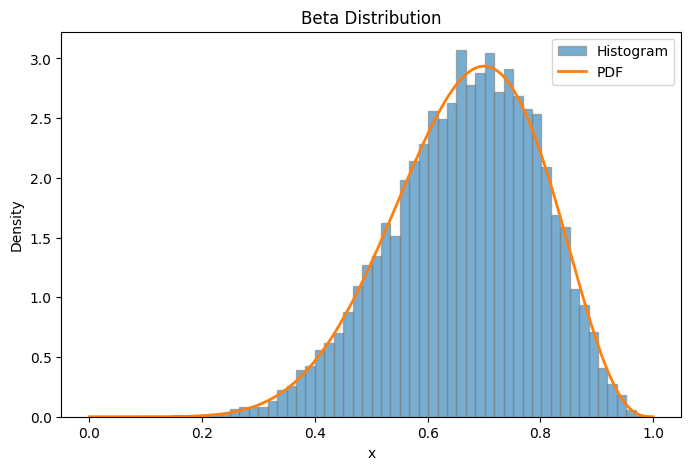

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# 生成 Beta 分布样本
alpha, beta_param = 8, 4
samples = np.random.beta(alpha, beta_param, size=10000)

# 绘制直方图 + PDF 曲线
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=50, density=True, alpha=0.6, edgecolor='gray', label='Histogram')
x = np.linspace(0, 1, 200)
pdf = beta.pdf(x, alpha, beta_param)
plt.plot(x, pdf, linewidth=2, label='PDF')
plt.title('Beta Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

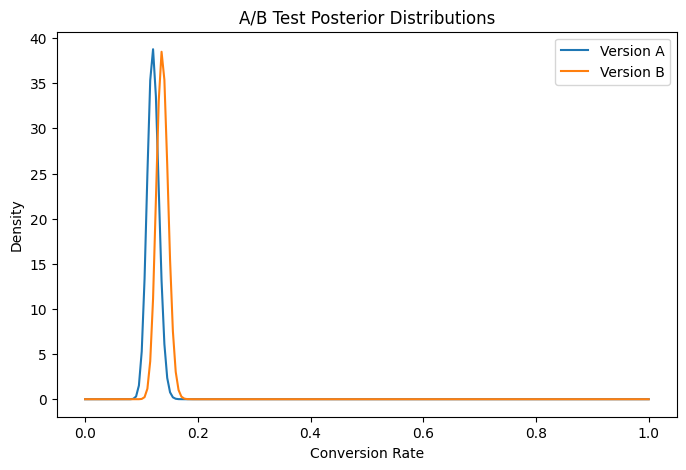

Probability that A is better than B: 0.133


In [2]:
import numpy as np
from scipy.stats import beta

# 假设版本 A：观测到 120 次转化 / 1000 次展示
#      版本 B：观测到 150 次转化 / 1100 次展示
a_success, a_trials = 120, 1000
b_success, b_trials = 150, 1100

# 设定非信息先验 Beta(1,1)
a_alpha_post = 1 + a_success
a_beta_post  = 1 + (a_trials - a_success)
b_alpha_post = 1 + b_success
b_beta_post  = 1 + (b_trials - b_success)

# 在 [0,1] 区间上比较两个后验分布
x = np.linspace(0, 1, 200)
a_pdf = beta.pdf(x, a_alpha_post, a_beta_post)
b_pdf = beta.pdf(x, b_alpha_post, b_beta_post)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(x, a_pdf, label='Version A')
plt.plot(x, b_pdf, label='Version B')
plt.title('A/B Test Posterior Distributions')
plt.xlabel('Conversion Rate')
plt.ylabel('Density')
plt.legend()
plt.show()

# 计算 P(A > B) 的概率（蒙特卡洛模拟）
samples_a = np.random.beta(a_alpha_post, a_beta_post, size=1000000)
samples_b = np.random.beta(b_alpha_post, b_beta_post, size=1000000)
prob_a_beats_b = np.mean(samples_a > samples_b)
print(f"Probability that A is better than B: {prob_a_beats_b:.3f}")